# Weekly Training Summary

Loads the consolidated `coach_input_{monday}.json` and displays an interactive overview of the current training week.

In [1]:
import json
from datetime import date, timedelta
from pathlib import Path

import pandas as pd

PROCESSED_DIR = Path("..") / "data" / "processed"

today = date.today()
monday = today - timedelta(days=today.weekday())
input_file = PROCESSED_DIR / f"coach_input_{monday.isoformat()}.json"

if not input_file.exists():
    files = sorted(PROCESSED_DIR.glob("coach_input_*.json"))
    input_file = files[-1]

data = json.loads(input_file.read_text())
print(f"Loaded: {input_file.name}")
print(f"Week starting: {data['week_starting']}")

Loaded: coach_input_2026-04-27.json
Week starting: 2026-04-27


## Athlete Metrics

In [2]:
m = data.get("metrics", {})
weight = m.get("weight") or 0

def w_per_kg(watts):
    if watts and weight:
        return round(watts / weight, 2)
    return None

metrics_display = {
    "FTP (W)": m.get("ftp"),
    "FTP (W/kg)": w_per_kg(m.get("ftp")),
    "Rolling FTP (W)": m.get("rolling_ftp"),
    "Rolling FTP (W/kg)": w_per_kg(m.get("rolling_ftp")),
    "eFTP (W)": round(m.get("eftp", 0), 1),
    "eFTP (W/kg)": w_per_kg(m.get("eftp")),
    "VO2Max (calc.)": m.get("vo2max"),
    "W\u2019 (J)": m.get("w_prime"),
    "Best 5-min Power (W)": m.get("p5min"),
    "Weight (kg)": weight,
    "CTL": round(m.get("ctl", 0), 1),
    "ATL": round(m.get("atl", 0), 1),
    "Resting HR (bpm)": m.get("resting_hr"),
    "HRV": m.get("hrv"),
}

pd.DataFrame(list(metrics_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
FTP (W),265.000
FTP (W/kg),3.570
Rolling FTP (W),258.000
Rolling FTP (W/kg),3.480
eFTP (W),258.200
eFTP (W/kg),3.480
VO2Max (calc.),54.700
W’ (J),18810.000
Best 5-min Power (W),319.000


## Week Summary

In [3]:

ws = data.get("week_summary", {})
tp = ws.get("training_plan")

if tp:
    # Support both old dict format and new list format
    if isinstance(tp, dict):
        tp = [tp]

    rows = []
    for entry in tp:
        week      = entry.get("week", "")
        plan_name = entry.get("plan_name") or "Training Plan"
        phase     = entry.get("phase")
        load      = entry.get("weekly_load_target")
        rows.append({
            "Week":         week,
            "Plan":         plan_name,
            "Phase":        f"#{phase}" if phase else "(no phase)",
            "Phase Period": f"{entry.get('phase_start', '')} → {entry.get('phase_end', '')}",
            "Load Target":  f"{load} TSS" if load is not None else "(none)",
        })

    display(pd.DataFrame(rows).set_index("Week"))
else:
    print("No training plan data available — run get_training_plan.py first.")


,Plan,Phase,Phase Period,Load Target
Week,,,,
2026-04-27,Training Plan,#Peak,2026-04-27 → 2026-05-04,319 TSS
2026-05-04,Training Plan,#Peak,2026-04-27 → 2026-05-04,(none)


In [4]:
ws = data.get("week_summary", {})

week_display = {
    "Rides": ws.get("number_of_rides"),
    "Total Load": ws.get("total_training_load"),
    "Total Time (h)": round(ws.get("total_time_hours", 0), 1),
    "Longest Ride (h)": round(ws.get("longest_ride_hours", 0), 1),
    "VO2 Sessions": ws.get("vo2_sessions"),
    "Threshold Sessions": ws.get("threshold_sessions"),
    "Long Ride Sessions": ws.get("long_ride_sessions"),
    "Endurance Sessions": ws.get("endurance_sessions"),
    "Avg Decoupling (%)": round(ws.get("avg_decoupling", 0), 1),
    "Avg Decoupling Label": ws.get("avg_decoupling_label", ""),
    "Rides with high drift or worse (>=8%)": ws.get("high_decoupling_rides"),
}

pd.DataFrame(list(week_display.items()), columns=["Metric", "Value"]).set_index("Metric")

,Value
Metric,
Rides,1
Total Load,171
Total Time (h),3.1
Longest Ride (h),3.1
VO2 Sessions,1
Threshold Sessions,0
Long Ride Sessions,0
Endurance Sessions,0
Avg Decoupling (%),10.4


## Activities

In [5]:
activities = data.get("activities", [])
df = pd.DataFrame(activities)

cols = [
    "date", "name", "duration_hours", "ride_type",
    "training_load", "avg_power", "norm_power",
    "polarization_index", "training_distribution",
    "z1_z2_pct", "z3_z4_pct", "z5_plus_pct",
    "decoupling", "rpe", "carbs_used_g", "carbs_ingested_g",
    "w_prime_j", "w_prime_bal_drop_j", "w_prime_bal_min_j", "w_prime_usage_pct",
]
cols = [c for c in cols if c in df.columns]
df[cols]


,date,name,duration_hours,training_load,avg_power,norm_power,polarization_index,training_distribution,z1_z2_pct,z3_z4_pct,z5_plus_pct,decoupling,rpe,carbs_used_g,carbs_ingested_g,w_prime_j,w_prime_bal_drop_j,w_prime_bal_min_j,w_prime_usage_pct
0,2026-04-21,Strictly GA1,2.43,81,115,153,1.05,Pyramidal,81.2,12.0,1.6,-5.101692,3,305,140,18810,2743,16067,14.6
1,2026-04-23,Threshold Over-Under 2x12 min,1.68,85,147,188,1.04,Unique,63.3,21.2,3.2,14.427207,6,269,60,18810,3904,14906,20.8
2,2026-04-25,Voraktivierung La Doyenne,0.64,22,142,155,2.79,Base,95.6,0.6,3.6,0.445585,5,115,0,18810,2108,16702,11.2
3,2026-04-26,La Doyenne – Côte de la Redoute All-Out,3.49,167,139,183,1.01,Unique,65.3,23.3,3.4,5.731796,5,441,360,18810,16884,1926,89.8
4,2026-04-28,BTS Gruppenausfahrt (VO2 Stimulus),3.07,171,145,198,1.90,Polarized,70.6,11.8,12.7,10.443332,8,434,260,18810,15718,3092,83.6


## Zone Distribution per Activity

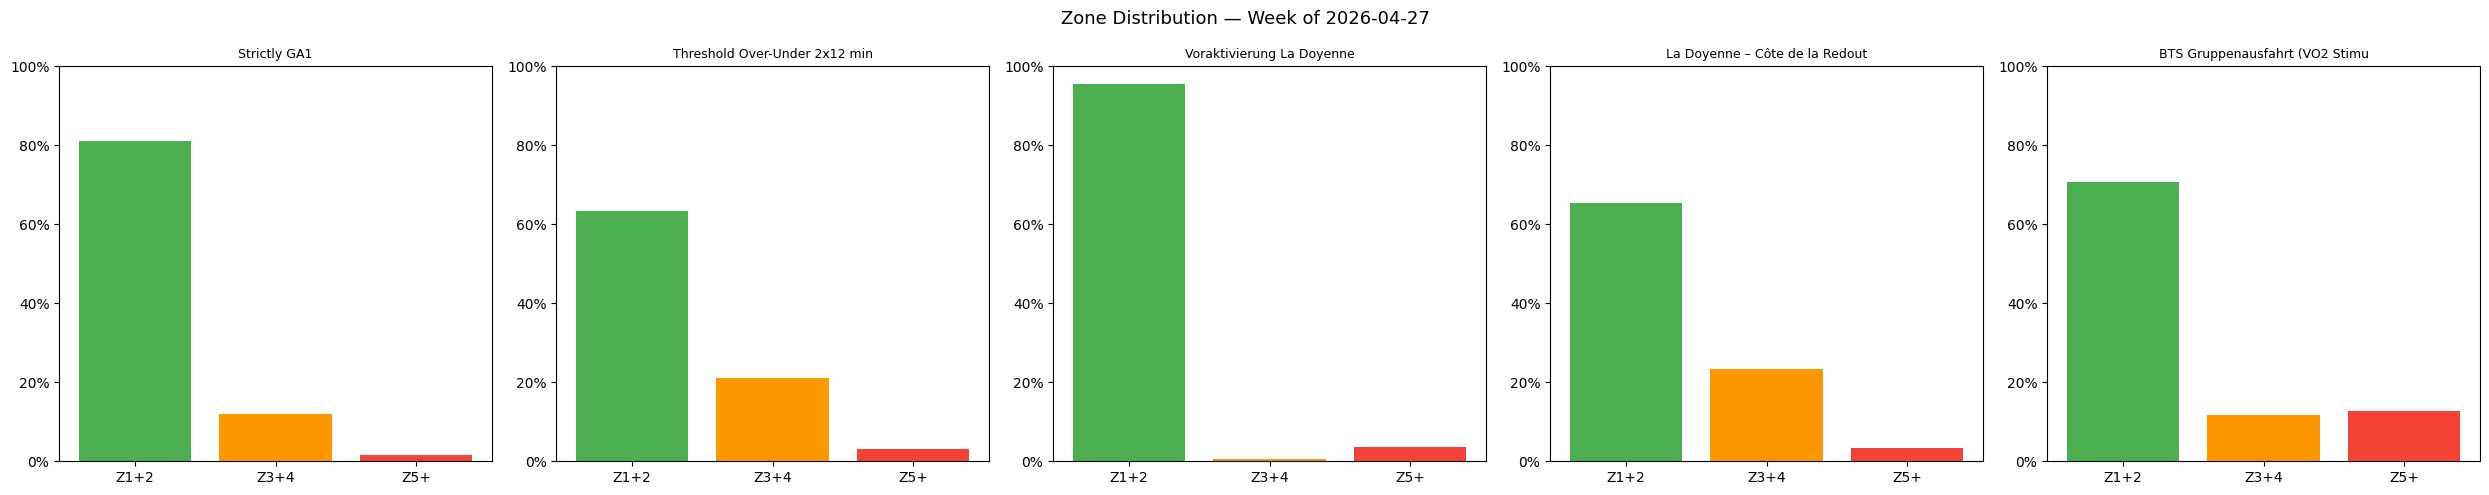

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

zone_df = df[["name", "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna()
n = len(zone_df)

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Zone Distribution \u2014 Week of {data['week_starting']}", fontsize=13)

    for ax, row in zip(axes, zone_df.itertuples()):
        values = [row.z1_z2_pct, row.z3_z4_pct, row.z5_plus_pct]
        labels = ["Z1+2", "Z3+4", "Z5+"]
        colors = ["#4caf50", "#ff9800", "#f44336"]
        ax.bar(labels, values, color=colors)
        ax.set_title(row.name[:30], fontsize=9)
        ax.set_ylim(0, 100)
        ax.yaxis.set_major_formatter(ticker.PercentFormatter())

    plt.tight_layout()
    plt.show()

## Training Distribution (Polarization Index)

,Activity,PI,Label,Reason,Z1+2 %,Z3+4 %,Z5+ %
Date,,,,,,,
2026-04-21,Strictly GA1,1.05,Pyramidal,"Z1+2 81.2% >= 70%, Z3+4 12.0% >= 10%, Z5+ 1.6%...",81.2,12.0,1.6
2026-04-23,Threshold Over-Under 2x12 min,1.04,Unique,"No pattern matched (Z1+2=63.3%, Z3+4=21.2%, Z5...",63.3,21.2,3.2
2026-04-25,Voraktivierung La Doyenne,2.79,Base,"Z1+2 95.6% >= 85%, Z3+4 0.6% < 10%, Z5+ 3.6% < 5%",95.6,0.6,3.6
2026-04-26,La Doyenne – Côte de la Redoute All-Out,1.01,Unique,"No pattern matched (Z1+2=65.3%, Z3+4=23.3%, Z5...",65.3,23.3,3.4
2026-04-28,BTS Gruppenausfahrt (VO2 Stimulus),1.90,Polarized,Z1+2 70.6% >= 70% and Z5+ 12.7% >= 10%,70.6,11.8,12.7


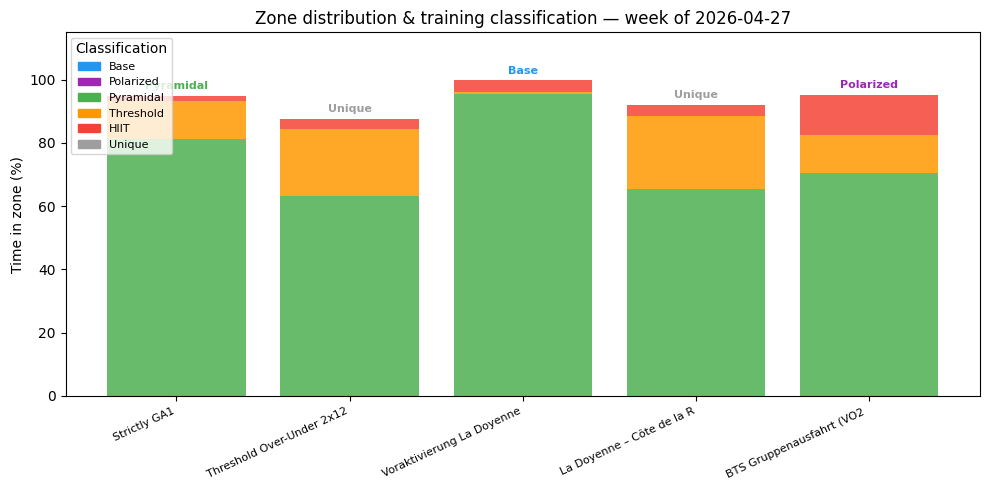


Distribution summary this week:
  Unique       2 ride(s)
  Pyramidal    1 ride(s)
  Base         1 ride(s)
  Polarized    1 ride(s)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

dist_df = df[["date", "name", "polarization_index", "training_distribution", "training_distribution_reason",
              "z1_z2_pct", "z3_z4_pct", "z5_plus_pct"]].dropna(subset=["training_distribution"])

# --- Table: label + reason per ride ---
if not dist_df.empty:
    display(dist_df.rename(columns={
        "date": "Date",
        "name": "Activity",
        "polarization_index": "PI",
        "training_distribution": "Label",
        "training_distribution_reason": "Reason",
        "z1_z2_pct": "Z1+2 %",
        "z3_z4_pct": "Z3+4 %",
        "z5_plus_pct": "Z5+ %",
    }).set_index("Date"))

    # --- Bar chart: stacked zone distribution coloured by label ---
    LABEL_COLORS = {
        "Base":       "#2196f3",
        "Polarized":  "#9c27b0",
        "Pyramidal":  "#4caf50",
        "Threshold":  "#ff9800",
        "HIIT":       "#f44336",
        "Unique":     "#9e9e9e",
    }

    labels = dist_df["training_distribution"].tolist()
    names  = [str(n)[:25] for n in dist_df["name"].tolist()]
    z1z2   = dist_df["z1_z2_pct"].tolist()
    z34    = dist_df["z3_z4_pct"].tolist()
    z5p    = dist_df["z5_plus_pct"].tolist()
    colors = [LABEL_COLORS.get(l, "#9e9e9e") for l in labels]

    x = range(len(names))
    fig, ax = plt.subplots(figsize=(max(8, 2 * len(names)), 5))
    bars1 = ax.bar(x, z1z2, label="Z1+2", color="#4caf50", alpha=0.85)
    bars2 = ax.bar(x, z34,  bottom=z1z2, label="Z3+4", color="#ff9800", alpha=0.85)
    bars3 = ax.bar(x, z5p,  bottom=[a + b for a, b in zip(z1z2, z34)], label="Z5+", color="#f44336", alpha=0.85)

    # Annotate label above each bar group
    for i, (lbl, col) in enumerate(zip(labels, colors)):
        total = z1z2[i] + z34[i] + z5p[i]
        ax.text(i, total + 1.5, lbl, ha="center", va="bottom", fontsize=8,
                fontweight="bold", color=col)

    ax.set_xticks(list(x))
    ax.set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Time in zone (%)")
    ax.set_ylim(0, 115)
    ax.set_title(f"Zone distribution & training classification — week of {data.get('week_starting', '')}")
    ax.legend(loc="upper right")

    # Legend patches for classification colours
    patches = [mpatches.Patch(color=c, label=l) for l, c in LABEL_COLORS.items()]
    ax.legend(handles=patches, loc="upper left", fontsize=8, title="Classification")

    plt.tight_layout()
    plt.show()

    # --- Summary: how many rides per label this week ---
    print("\nDistribution summary this week:")
    for lbl, cnt in dist_df["training_distribution"].value_counts().items():
        print(f"  {lbl:<12} {cnt} ride(s)")
else:
    print("No training_distribution data available — run prepare_activities_for_coach.py first.")


## Form & Fatigue Analysis

In [8]:
ctl = data.get("metrics", {}).get("ctl") or 0
atl = data.get("metrics", {}).get("atl") or 0
hrv = data.get("metrics", {}).get("hrv")
ws = data.get("week_summary", {})

form_absolute = ws.get("form_absolute")
form_pct = ws.get("form_pct")
form_percent_display = ws.get("form_percent_display")
form_zone = ws.get("form_zone", "n/a")

form_display = {
    "CTL (Fitness)": round(ctl, 1),
    "ATL (Fatigue)": round(atl, 1),
    "Form (absolute)": form_absolute,
    "Form (%)": f"{form_percent_display:.1f}%" if form_percent_display is not None else "n/a",
    "Form Zone": form_zone,
    "HRV": hrv,
}

display(pd.DataFrame(list(form_display.items()), columns=["Metric", "Value"]).set_index("Metric"))

print("\n=== Coaching Interpretation ===")
# Zones based on form_pct (%), matching intervals.icu definition
if form_pct is not None:
    if form_pct > 0.20:
        print("Form:  Transition (> 20 %) → well rested, consider increasing load")
    elif form_pct >= 0.05:
        print("Form:  Fresh (5–20 %) → race-ready or high-intensity sessions")
    elif form_pct >= -0.10:
        print("Form:  Grey Zone (-10 to 5 %) → moderate fatigue, maintain structure")
        if hrv is not None and hrv < 50:
            print("HRV:   Low HRV signal → consider an easier day")
    elif form_pct >= -0.30:
        print("Form:  Optimal training zone (-30 to -10 %) → proceed with key sessions")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
    else:
        print("Form:  High fatigue (below -30 %) → reduce intensity and prioritize recovery")
        if hrv is not None and hrv < 50:
            print("HRV:   Strong fatigue signal combined with low HRV → recommend rest day")
else:
    print("Form data not available — run prepare_week_for_coach.py first.")


,Value
Metric,
CTL (Fitness),59.9
ATL (Fatigue),62.7
Form (absolute),-2.8
Form (%),-4.7%
Form Zone,grey_zone
HRV,62.0



=== Coaching Interpretation ===
Form:  Grey Zone (-10 to 5 %) → moderate fatigue, maintain structure


## Form & Fatigue History

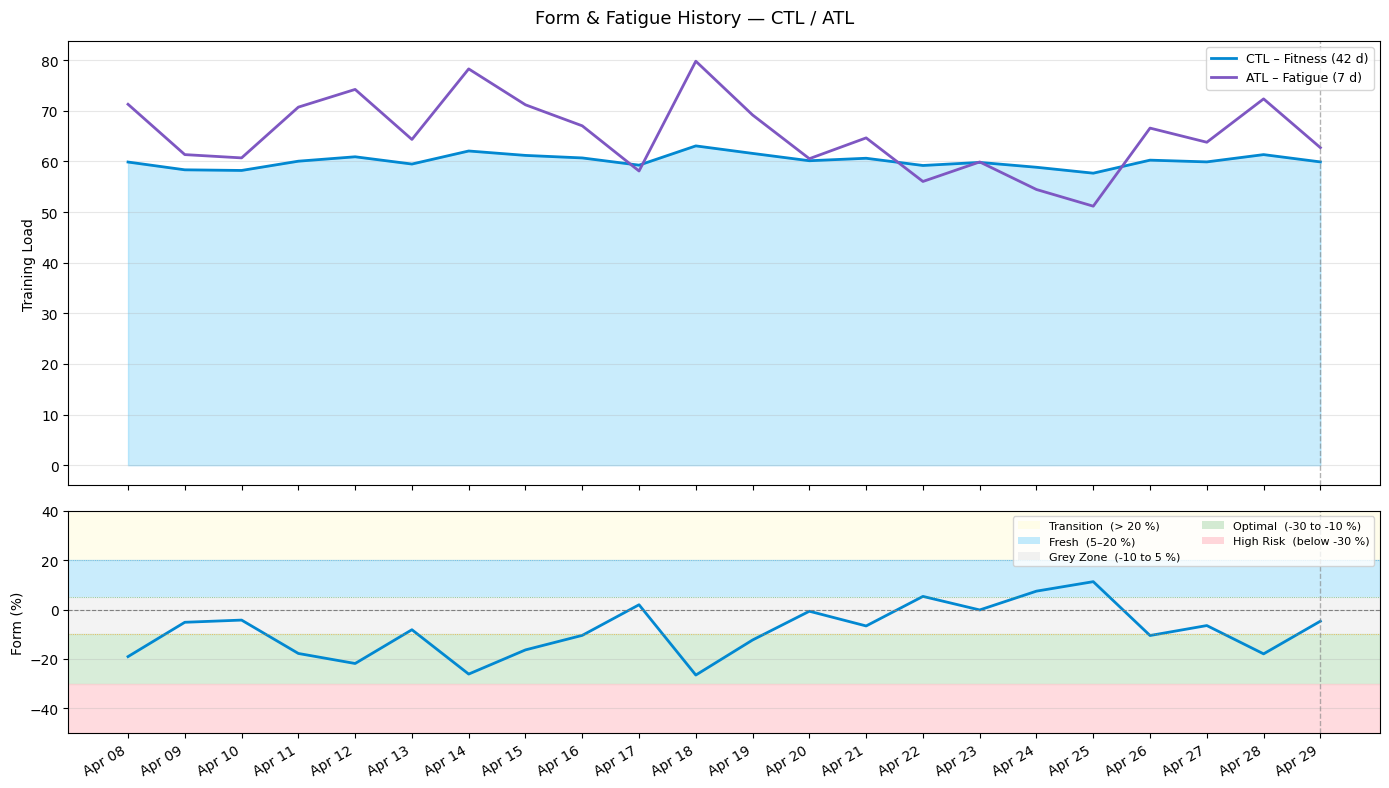


Data points: 22  |  Range: 2026-04-08 → 2026-04-29
Today  →  CTL: 59.9  |  ATL: 62.7  |  Form: -4.7%


In [9]:
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Load all available metrics snapshots from data/processed/
metrics_files = sorted(PROCESSED_DIR.glob("metrics_*.json"))
hist = []
for f in metrics_files:
    try:
        d = json.loads(f.read_text())
        if d.get("ctl") is not None and d.get("atl") is not None:
            hist.append(d)
    except Exception:
        pass

if len(hist) >= 2:
    dates     = [pd.to_datetime(d["date"]) for d in hist]
    ctl_vals  = [d["ctl"]  for d in hist]
    atl_vals  = [d["atl"]  for d in hist]
    # form_pct in % (matching intervals.icu zone definitions)
    form_vals = [(d["ctl"] - d["atl"]) / d["ctl"] * 100 if d["ctl"] else 0 for d in hist]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )
    fig.suptitle("Form & Fatigue History — CTL / ATL", fontsize=13)

    # ── Top panel: CTL filled area + ATL line ──
    ax1.fill_between(dates, ctl_vals, alpha=0.25, color="#29b6f6")
    ax1.plot(dates, ctl_vals, color="#0288d1", linewidth=2, label="CTL – Fitness (42 d)")
    ax1.plot(dates, atl_vals, color="#7e57c2", linewidth=2, label="ATL – Fatigue (7 d)")
    ax1.set_ylabel("Training Load")
    ax1.legend(loc="upper right", fontsize=9)
    ax1.grid(axis="y", alpha=0.3)

    # ── Bottom panel: form zones (form_pct %, intervals.icu) + form line ──
    ax2.axhspan( 20,  50, color="#fffde7", alpha=0.80, zorder=0)   # Transition (light yellow)
    ax2.axhspan(  5,  20, color="#b3e5fc", alpha=0.70, zorder=0)   # Fresh (light blue)
    ax2.axhspan(-10,   5, color="#eeeeee", alpha=0.70, zorder=0)   # Grey Zone
    ax2.axhspan(-30, -10, color="#c8e6c9", alpha=0.70, zorder=0)   # Optimal (green)
    ax2.axhspan(-60, -30, color="#ffcdd2", alpha=0.70, zorder=0)   # High Risk (red)

    ax2.plot(dates, form_vals, color="#0288d1", linewidth=2, label="Form (%)")
    ax2.axhline(0,  color="grey",    linewidth=0.8, linestyle="--")
    ax2.axhline( 5, color="#4caf50", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(20, color="#29b6f6", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.axhline(-10, color="#ff9800", linewidth=0.6, linestyle=":", alpha=0.7)
    ax2.set_ylabel("Form (%)")
    ax2.set_ylim(-50, 40)

    legend_els = [
        Patch(facecolor="#fffde7", alpha=0.9, label="Transition  (> 20 %)"),
        Patch(facecolor="#b3e5fc", alpha=0.8, label="Fresh  (5–20 %)"),
        Patch(facecolor="#eeeeee", alpha=0.8, label="Grey Zone  (-10 to 5 %)"),
        Patch(facecolor="#c8e6c9", alpha=0.8, label="Optimal  (-30 to -10 %)"),
        Patch(facecolor="#ffcdd2", alpha=0.8, label="High Risk  (below -30 %)"),
    ]
    ax2.legend(handles=legend_els, loc="upper right", fontsize=8, ncol=2)
    ax2.grid(axis="y", alpha=0.3)

    # Set ticks only at actual data dates to avoid duplicates with sparse history
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    if len(dates) <= 60:
        ax2.set_xticks(dates)
    else:
        ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.xticks(rotation=30, ha="right")

    # Mark today
    today_ts = pd.Timestamp.today().normalize()
    for ax in (ax1, ax2):
        ax.axvline(today_ts, color="grey", linewidth=1, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

    print(f"\nData points: {len(hist)}  |  Range: {hist[0]['date']} → {hist[-1]['date']}")
    print(f"Today  →  CTL: {ctl_vals[-1]:.1f}  |  ATL: {atl_vals[-1]:.1f}  |  Form: {form_vals[-1]:.1f}%")
else:
    print(f"Not enough historical data ({len(hist)} snapshot(s) found).")
    print("Run get_metrics.py on multiple days to build up a history.")


## Integrated Fatigue & Fueling Analysis

In [10]:
ff = ws.get("fueling_form_analysis", {})

if ff:
    form_pct_display = ws.get('form_percent_display', 0)
    interpretation = ff.get('interpretation', '')
    recommendation = ff.get('recommendation', '')
    long_ride_advice = ff.get('long_ride_advice')

    ff_display = {
        "Form (%)": f"{form_pct_display:.1f}%",
        "Fatigue Status": ff.get("fatigue_status"),
        "Avg Carbs/h (g)": ff.get("avg_carbs_per_hour"),
        "Fueling Status": ff.get("fueling_status"),
        "Underfueled Sessions": ff.get("underfueled_sessions"),
        "Durability Limited by Fueling": ff.get("durability_limited_by_fueling"),
        "Long Rides": ff.get("number_of_long_rides"),
    }
    display(pd.DataFrame(list(ff_display.items()), columns=["Metric", "Value"]).set_index("Metric"))
    print()
    print(f"Interpretation: {interpretation}")
    print(f"Recommendation: {recommendation}")
    if long_ride_advice:
        print(f"Long rides:     {long_ride_advice}")
else:
    print("No integrated analysis available — run prepare_week_for_coach.py first.")


,Value
Metric,
Form (%),-4.7%
Fatigue Status,low
Avg Carbs/h (g),0.0
Fueling Status,low
Underfueled Sessions,0
Durability Limited by Fueling,False
Long Rides,0



Interpretation: Low load but also underfueled (suboptimal adaptation)
Recommendation: Increase fueling even on lower-intensity days
Long rides:     Add a long aerobic ride this week


## Fueling Analysis

In [11]:
fueling = data.get("fueling_analysis", {})
fa = fueling.get("activities", [])

if fa:
    df_fuel = pd.DataFrame(fa)
    fuel_cols = [
        "date", "name", "duration_hours", "fueling_status", "ride_type",
        "carbs_per_hour", "carbs_classification", "fueling_ratio",
        "ratio_classification", "is_long_ride", "flags",
    ]
    fuel_cols = [c for c in fuel_cols if c in df_fuel.columns]
    display(df_fuel[fuel_cols])

    fs = fueling.get("weekly_summary", {})
    print(f"\nLong rides:           {fs.get('number_of_long_rides')}")
    print(f"Avg carbs/h:          {fs.get('avg_carbs_per_hour')} g")
    print(f"Avg fueling ratio:    {fs.get('avg_fueling_ratio')}")
    print(f"Underfueled sessions: {fs.get('number_of_underfueled_sessions')}")

    print("\nRecommendations:")
    for r in fueling.get("recommendations", []):
        print(f"  * {r}")

,date,name,duration_hours,fueling_status,ride_type,carbs_per_hour,carbs_classification,fueling_ratio,ratio_classification,is_long_ride,flags
0,2026-04-21,Strictly GA1,2.43,fueling required,endurance,57.6,low,0.46,moderate deficit,False,[]
1,2026-04-23,Threshold Over-Under 2x12 min,1.68,fueling optional,threshold,35.7,optional,0.22,optional,False,[]
2,2026-04-25,Voraktivierung La Doyenne,0.64,no fueling needed,recovery,0.0,not required,0.00,not applicable,False,[]
3,2026-04-26,La Doyenne – Côte de la Redoute All-Out,3.49,fueling required,threshold,103.2,high,0.82,good,False,[]
4,2026-04-28,BTS Gruppenausfahrt (VO2 Stimulus),3.07,fueling required,vo2,84.7,good,0.60,acceptable,False,[]



Long rides:           0
Avg carbs/h:          0 g
Avg fueling ratio:    None
Underfueled sessions: 0

Recommendations:
  * Short rides do not require fueling — focus on long sessions.


## Planned Workouts

In [12]:
planned = data.get("planned_workouts")

def _show_planned_table(workouts: list, week_label: str) -> None:
    if not workouts:
        print(f"{week_label}: no planned workouts found.")
        return

    rows = []
    for w in workouts:
        zd = w.get("zone_distribution") or {}
        rows.append({
            "Date": w.get("date"),
            "Time": w.get("time"),
            "Name": w.get("name"),
            "Type": w.get("type"),
            "Duration (h)": w.get("duration_hours"),
            "Planned Load": w.get("planned_load"),
            "Z1+2 %": zd.get("z1_z2_pct"),
            "Z3+4 %": zd.get("z3_z4_pct"),
            "Z5+ %": zd.get("z5_plus_pct"),
        })

    df_plan = pd.DataFrame(rows).set_index("Date")
    print(f"\n### {week_label}")
    display(df_plan)


if planned:
    _show_planned_table(
        planned.get("current_week", {}).get("planned_workouts", []),
        f"Current week  ({planned.get('current_week', {}).get('week_starting', '')})",
    )
    _show_planned_table(
        planned.get("next_week", {}).get("planned_workouts", []),
        f"Next week  ({planned.get('next_week', {}).get('week_starting', '')})",
    )
else:
    print("No planned workout data available — run prepare_week_for_coach.py first.")



### Current week  (2026-04-27)


,Time,Name,Type,Duration (h),Planned Load,Z1+2 %,Z3+4 %,Z5+ %
Date,,,,,,,,
2026-04-29,00:00,Ruhetag,Ride,NaN,NaN,NaN,NaN,NaN
2026-04-30,00:00,Grundlage 2h,Ride,2.00,97.0,100.0,0.0,0.0
2026-05-01,00:00,Schwelle 3x8 min,Ride,1.25,57.0,38.5,30.8,0.0
2026-05-02,00:00,Endurance Ride,Ride,2.00,92.0,100.0,0.0,0.0


Next week  (2026-05-04): no planned workouts found.


### Workout Step Structure

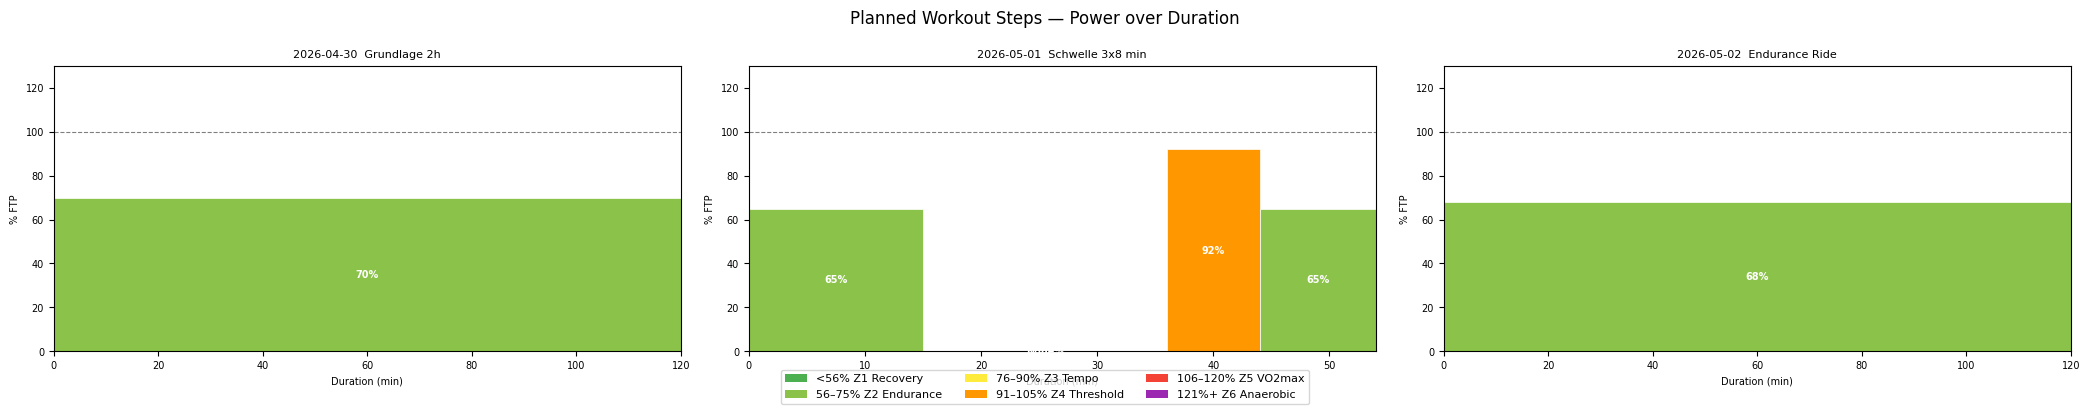

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def _zone_color(pct_ftp: float | None) -> str:
    """Return a color based on % FTP to visualise intensity."""
    if pct_ftp is None:
        return "#9e9e9e"
    if pct_ftp < 56:
        return "#4caf50"   # Z1 – Active Recovery
    if pct_ftp < 76:
        return "#8bc34a"   # Z2 – Endurance
    if pct_ftp < 91:
        return "#ffeb3b"   # Z3 – Tempo
    if pct_ftp < 106:
        return "#ff9800"   # Z4 – Threshold
    if pct_ftp < 121:
        return "#f44336"   # Z5 – VO2max
    return "#9c27b0"       # Z6+ – Anaerobic / Neuromuscular


def _plot_workout_steps(ax: plt.Axes, steps: list[dict], title: str) -> None:
    """Draw a horizontal step-bar chart (power-over-time style) on ax."""
    if not steps:
        ax.text(0.5, 0.5, "No steps", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title[:40], fontsize=8)
        return

    x = 0.0
    for step in steps:
        dur = step.get("duration_min") or 0
        pct = step.get("power_pct_ftp")
        height = pct if pct is not None else 0
        color = _zone_color(pct)
        ax.bar(x + dur / 2, height, width=dur, color=color, align="center", edgecolor="white", linewidth=0.5)
        if dur >= 4:
            ax.text(x + dur / 2, height / 2, f"{pct}%", ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")
        x += dur

    ax.set_xlim(0, x)
    ax.set_ylim(0, 130)
    ax.set_xlabel("Duration (min)", fontsize=7)
    ax.set_ylabel("% FTP", fontsize=7)
    ax.set_title(title[:40], fontsize=8)
    ax.tick_params(labelsize=7)
    # FTP reference line
    ax.axhline(100, color="black", linewidth=0.8, linestyle="--", alpha=0.5)


def _collect_workouts_with_steps(planned: dict) -> list[dict]:
    result = []
    for week_key in ("current_week", "next_week"):
        week = planned.get(week_key, {})
        for w in week.get("planned_workouts", []):
            steps = w.get("steps")
            if steps:
                result.append(w)
    return result


if planned:
    workouts_with_steps = _collect_workouts_with_steps(planned)
    if workouts_with_steps:
        n = len(workouts_with_steps)
        ncols = min(n, 3)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n > 1 else [axes]

        for ax, w in zip(axes_flat, workouts_with_steps):
            title = f"{w.get('date')}  {w.get('name', '')}"
            _plot_workout_steps(ax, w.get("steps", []), title)

        # Hide unused subplots
        for ax in axes_flat[n:]:
            ax.set_visible(False)

        # Zone legend
        zone_labels = [
            ("<56% Z1 Recovery", "#4caf50"),
            ("56–75% Z2 Endurance", "#8bc34a"),
            ("76–90% Z3 Tempo", "#ffeb3b"),
            ("91–105% Z4 Threshold", "#ff9800"),
            ("106–120% Z5 VO2max", "#f44336"),
            ("121%+ Z6 Anaerobic", "#9c27b0"),
        ]
        patches = [mpatches.Patch(facecolor=c, label=l) for l, c in zone_labels]
        fig.legend(handles=patches, loc="lower center", ncol=3, fontsize=8,
                   bbox_to_anchor=(0.5, -0.02))

        fig.suptitle("Planned Workout Steps — Power over Duration", fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        print("No workouts with step data available.")
else:
    print("No planned workout data available — run prepare_week_for_coach.py first.")


## W'bal Analysis

Detailed anaerobic reserve analysis for high-intensity activities.
Computed from the second-by-second power stream (Skiba differential model).
Only activities meeting at least one intensity criterion (≥8 % Z5+, interval ≥105 % FTP / ≥2 min, or vo2 / event tag) receive a W'bal summary.


,Date,W' (J),Min W'bal (J),Depletion (J),Usage (%),s < 30 %,s < 10 %,Depletion Events,Recovery Ratio
Activity,,,,,,,,,
La Doyenne – Côte de la Redoute All-Out,2026-04-26,18810.0,4186.1,14623.9,77.7,49,0,1,1.0
BTS Gruppenausfahrt (VO2 Stimulus),2026-04-28,18810.0,3330.4,15479.6,82.3,242,0,3,1.0


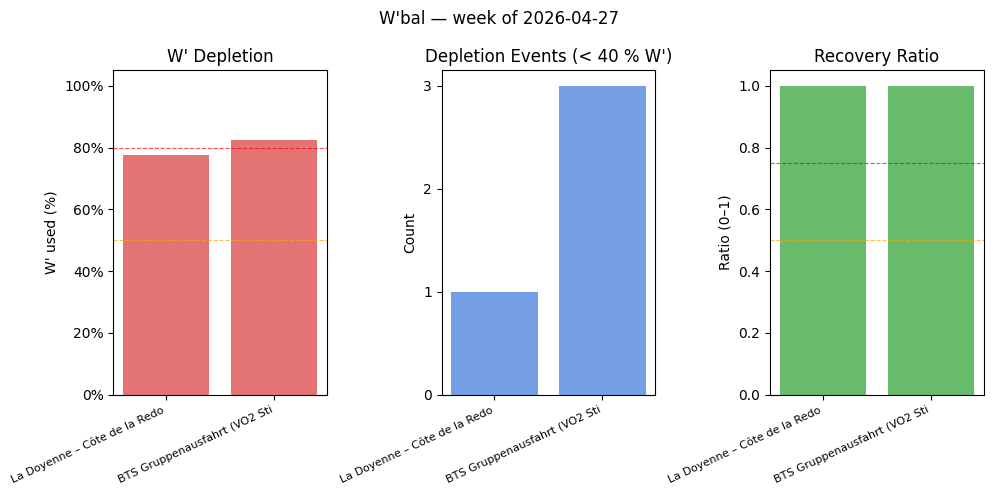

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

wbal_rows = []
for act in data.get("activities", []):
    ws = act.get("wbal_summary")
    if not ws:
        continue
    wbal_rows.append({
        "Activity":             act.get("name", ""),
        "Date":                 act.get("date", ""),
        "W' (J)":               ws.get("w_prime_j"),
        "Min W'bal (J)":        ws.get("wbal_min_j"),
        "Depletion (J)":        ws.get("wbal_max_depletion_j"),
        "Usage (%)":            ws.get("wbal_usage_pct"),
        "s < 30 %":             ws.get("seconds_below_30pct"),
        "s < 10 %":             ws.get("seconds_below_10pct"),
        "Depletion Events":     ws.get("wbal_depletion_events"),
        "Recovery Ratio":       ws.get("wbal_recovery_ratio"),
    })

if wbal_rows:
    wbal_df = pd.DataFrame(wbal_rows).set_index("Activity")
    display(wbal_df)

    # --- Bar chart: W' usage per activity ---
    names      = [r["Activity"][:28] for r in wbal_rows]
    usage_pct  = [r["Usage (%)"] or 0 for r in wbal_rows]
    events     = [r["Depletion Events"] or 0 for r in wbal_rows]
    rec_ratios = [r["Recovery Ratio"] for r in wbal_rows]

    x = list(range(len(names)))
    fig, axes = plt.subplots(1, 3, figsize=(max(10, 3.5 * len(names)), 5))
    fig.suptitle(f"W'bal — week of {data.get('week_starting', '')}", fontsize=12)

    # Panel 1: W' usage %
    axes[0].bar(x, usage_pct, color="#e05c5c", alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[0].set_ylabel("W' used (%)")
    axes[0].set_ylim(0, 105)
    axes[0].yaxis.set_major_formatter(ticker.PercentFormatter())
    axes[0].set_title("W' Depletion")
    axes[0].axhline(50, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)
    axes[0].axhline(80, color="red",    linestyle="--", linewidth=0.8, alpha=0.7)

    # Panel 2: Depletion events count
    axes[1].bar(x, events, color="#5c8ee0", alpha=0.85)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[1].set_ylabel("Count")
    axes[1].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    axes[1].set_title("Depletion Events (< 40 % W')")

    # Panel 3: Recovery ratio
    rec_vals = [r if r is not None else 0 for r in rec_ratios]
    bar_colors = ["#4caf50" if v >= 0.75 else "#ff9800" if v >= 0.5 else "#f44336" for v in rec_vals]
    axes[2].bar(x, rec_vals, color=bar_colors, alpha=0.85)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(names, rotation=25, ha="right", fontsize=8)
    axes[2].set_ylabel("Ratio (0–1)")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title("Recovery Ratio")
    axes[2].axhline(0.75, color="green",  linestyle="--", linewidth=0.8, alpha=0.7)
    axes[2].axhline(0.50, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("No W'bal data available — run prepare_activities_for_coach.py first.")
    print("(Only activities with ≥8 % Z5+, high-intensity intervals, vo2 or event tags are analysed.)")
